# Graph Search Algorithms — BFS / DFS / A\*

โน้ตบุ๊กสาธิตอัลกอริทึมค้นหาเส้นทางบนกราฟ แบบ **รันได้เองในตัว** (self-contained)

| อัลกอริทึม | โครงสร้างข้อมูล | เครื่องมือ |
|-----------|-----------------|-----------|
| **BFS** | คิว (FIFO) | `collections.deque` |
| **DFS** | สแตก (LIFO) | `list` / recursion |
| **A\*** | priority queue | `heapq` |

สร้างกราฟทดสอบด้วย `networkx` และแสดงผลด้วย `matplotlib`

> 💡 **อยากหาโหนดอื่น?** ข้ามไป **ส่วนที่ 6** ด้านล่าง จะมีช่องเลือกโหนดเริ่มต้น/ปลายทางเองได้ (เช่น A → I)


## 0. Setup — import ไลบรารีและตั้งค่าฟอนต์ไทย

In [1]:
import math
import heapq
import itertools
from collections import deque

import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# แสดงกราฟแบบ inline ในโน้ตบุ๊ก
%matplotlib inline

# เลือกฟอนต์ไทยตัวแรกที่เจอในระบบ เพื่อไม่ให้ตัวอักษรเป็นกล่อง
for _name in ["Thonburi", "Sukhumvit Set", "Sarabun", "Tahoma", "Ayuthaya"]:
    if _name in {f.name for f in font_manager.fontManager.ttflist}:
        matplotlib.rcParams["font.family"] = _name
        break
matplotlib.rcParams["axes.unicode_minus"] = False
print("matplotlib font:", matplotlib.rcParams["font.family"])

matplotlib font: ['Thonburi']


## 1. สร้างกราฟทดสอบ (networkx)

- โหนดแต่ละตัวมีพิกัด `(x, y)` เก็บใน attribute `pos`
- น้ำหนัก edge = ระยะทางยุคลิด (Euclidean) ระหว่างโหนด → ใช้กับ A\*
- BFS/DFS จะมองกราฟแบบไม่มีน้ำหนัก (นับจำนวนขั้น)


In [2]:
def euclidean(p1, p2):
    """ระยะทางเส้นตรง ใช้เป็นน้ำหนัก edge และ heuristic ของ A*"""
    return math.hypot(p1[0] - p2[0], p1[1] - p2[1])


def build_graph():
    """คืนค่า (G, start, goal) — กราฟถนนจำลอง 12 โหนด (A-L)"""
    G = nx.Graph()
    positions = {
        "A": (0, 0),  "B": (2, 1),  "C": (2, -1),
        "D": (4, 2),  "E": (4, 0),  "F": (4, -2),
        "G": (6, 1),  "H": (6, -1),
        "I": (8, 2),  "J": (8, 0),  "K": (8, -2),
        "L": (10, 0),
    }
    for node, pos in positions.items():
        G.add_node(node, pos=pos)

    edges = [
        ("A", "B"), ("A", "C"),
        ("B", "D"), ("B", "E"),
        ("C", "E"), ("C", "F"),
        ("D", "G"), ("E", "G"), ("E", "H"),
        ("F", "H"),
        ("G", "I"), ("G", "J"),
        ("H", "J"), ("H", "K"),
        ("I", "L"), ("J", "L"), ("K", "L"),
    ]
    for u, v in edges:
        w = euclidean(positions[u], positions[v])
        G.add_edge(u, v, weight=round(w, 2))
    return G, "A", "L"


G, start, goal = build_graph()
print(f"โหนด {G.number_of_nodes()} ตัว, เส้นเชื่อม {G.number_of_edges()} เส้น | {start} -> {goal}")

โหนด 12 ตัว, เส้นเชื่อม 17 เส้น | A -> L


ลองวาดกราฟพื้นฐานดูก่อน (สีเขียว = จุดเริ่ม, สีส้ม = เป้าหมาย)

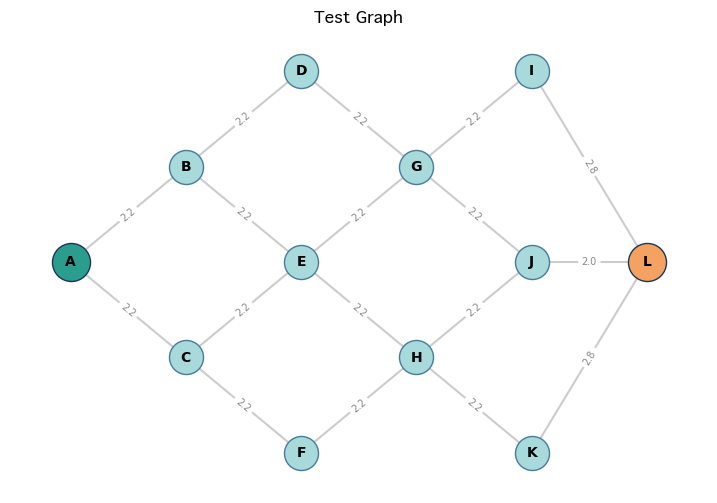

In [3]:
def draw_single(G, ax, title, path=None, start=None, goal=None, path_color="#e63946"):
    """วาดกราฟลงบน ax พร้อมไฮไลต์เส้นทาง path"""
    pos = nx.get_node_attributes(G, "pos")
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#cccccc", width=1.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#a8dadc",
                           node_size=600, edgecolors="#457b9d")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")
    edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=edge_labels,
                                 font_size=7, font_color="#888888")
    if path:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=path_edges,
                               edge_color=path_color, width=3.0)
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=path,
                               node_color=path_color, node_size=650, edgecolors="#1d3557")
    if start:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[start],
                               node_color="#2a9d8f", node_size=750, edgecolors="#1d3557")
    if goal:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[goal],
                               node_color="#f4a261", node_size=750, edgecolors="#1d3557")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")


fig, ax = plt.subplots(figsize=(9, 6))
draw_single(G, ax, "Test Graph", start=start, goal=goal)
plt.show()

## 2. BFS — Breadth-First Search (`collections.deque`)

ใช้ **คิว (FIFO)** สำรวจทีละชั้น → รับประกันเส้นทางที่ **จำนวนขั้นน้อยที่สุด** (กราฟไม่มีน้ำหนัก)


In [4]:
def bfs(G, start, goal):
    """คืนค่า (path, order) — order คือลำดับการเยี่ยมโหนด"""
    queue = deque([start])          # คิว FIFO
    visited = {start}
    parent = {start: None}
    order = []
    while queue:
        node = queue.popleft()      # ดึงจากหัวคิว
        order.append(node)
        if node == goal:
            # ย้อนสร้างเส้นทางจาก goal กลับไป start
            path = []
            while node is not None:
                path.append(node)
                node = parent[node]
            return path[::-1], order
        for nb in sorted(G.neighbors(node)):
            if nb not in visited:
                visited.add(nb)
                parent[nb] = node
                queue.append(nb)
    return None, order


bfs_path, bfs_order = bfs(G, start, goal)
print("ลำดับการเยี่ยม:", bfs_order)
print("เส้นทาง        :", bfs_path, f"({len(bfs_path) - 1} ขั้น)")

ลำดับการเยี่ยม: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
เส้นทาง        : ['A', 'B', 'D', 'G', 'I', 'L'] (5 ขั้น)


## 3. DFS — Depth-First Search (`list` / recursion)

ลงลึกไปทางเดียวจนสุดก่อนแล้วถอยกลับ (backtrack) → เจอ **เส้นทางใดเส้นทางหนึ่ง** (ไม่จำเป็นต้องสั้น)
มีให้สองแบบ: recursion และ list-stack


In [5]:
def dfs_recursive(G, start, goal):
    """DFS ด้วย recursion (call stack ทำหน้าที่เป็น stack)"""
    visited = set()
    order = []

    def visit(node, path):
        visited.add(node)
        order.append(node)
        if node == goal:
            return list(path)
        for nb in sorted(G.neighbors(node)):
            if nb not in visited:
                result = visit(nb, path + [nb])
                if result is not None:
                    return result
        return None

    return visit(start, [start]), order


def dfs_iterative(G, start, goal):
    """DFS ด้วย list เป็น stack (LIFO)"""
    stack = [[start]]
    visited = set()
    order = []
    while stack:
        path = stack.pop()          # ดึงจากท้าย list
        node = path[-1]
        if node in visited:
            continue
        visited.add(node)
        order.append(node)
        if node == goal:
            return path, order
        for nb in sorted(G.neighbors(node), reverse=True):
            if nb not in visited:
                stack.append(path + [nb])
    return None, order


dfs_path, dfs_order = dfs_recursive(G, start, goal)
print("recursive  ->", dfs_path)
print("iterative  ->", dfs_iterative(G, start, goal)[0])
print(f"เส้นทาง DFS ({len(dfs_path) - 1} ขั้น)")

recursive  -> ['A', 'B', 'D', 'G', 'E', 'C', 'F', 'H', 'J', 'L']
iterative  -> ['A', 'B', 'D', 'G', 'E', 'C', 'F', 'H', 'J', 'L']
เส้นทาง DFS (9 ขั้น)


## 4. A\* Search (`heapq`)

เลือกขยายโหนดที่ค่า **f(n) = g(n) + h(n)** ต่ำสุดก่อน
- `g(n)` = ต้นทุนจริงจาก start (รวมน้ำหนัก edge)
- `h(n)` = heuristic ระยะตรงไป goal (admissible → รับประกัน optimal)

`heapq` เป็น min-heap จึงดึงโหนด f ต่ำสุดได้ใน O(log n)


In [6]:
def astar(G, start, goal):
    """คืนค่า (path, order, cost)"""
    pos = nx.get_node_attributes(G, "pos")

    def h(node):
        return euclidean(pos[node], pos[goal])

    counter = itertools.count()     # tie-break กรณี f เท่ากัน
    open_heap = [(h(start), 0.0, next(counter), start, [start])]
    best_g = {start: 0.0}
    order = []
    while open_heap:
        f, g, _, node, path = heapq.heappop(open_heap)   # ดึง f ต่ำสุด
        order.append(node)
        if node == goal:
            return path, order, round(g, 2)
        for nb in G.neighbors(node):
            new_g = g + G[node][nb]["weight"]
            if nb not in best_g or new_g < best_g[nb]:
                best_g[nb] = new_g
                heapq.heappush(open_heap,
                               (new_g + h(nb), new_g, next(counter), nb, path + [nb]))
    return None, order, None


astar_path, astar_order, astar_cost = astar(G, start, goal)
print("ลำดับการขยาย:", astar_order)
print("เส้นทาง       :", astar_path, f"({len(astar_path) - 1} ขั้น)")
print("ต้นทุนรวม     :", astar_cost, "(ต่ำสุด - optimal)")

ลำดับการขยาย: ['A', 'B', 'C', 'E', 'D', 'F', 'G', 'H', 'J', 'L']
เส้นทาง       : ['A', 'B', 'E', 'G', 'J', 'L'] (5 ขั้น)
ต้นทุนรวม     : 10.96 (ต่ำสุด - optimal)


## 5. ฟังก์ชันรวม `run_search(start, goal)` — เรียกใช้ซ้ำได้

รวมทั้งสามอัลกอริทึมไว้ในฟังก์ชันเดียว: รับโหนดเริ่มต้น/ปลายทาง แล้วพิมพ์สรุป + วาดรูปเปรียบเทียบ


ค้นหา A -> L
  BFS : ['A', 'B', 'D', 'G', 'I', 'L']  (5 hops, cost 11.79)
  DFS : ['A', 'B', 'D', 'G', 'E', 'C', 'F', 'H', 'J', 'L']  (9 hops, cost 19.92)
  A*  : ['A', 'B', 'E', 'G', 'J', 'L']  (5 hops, cost 10.96)  <- optimal


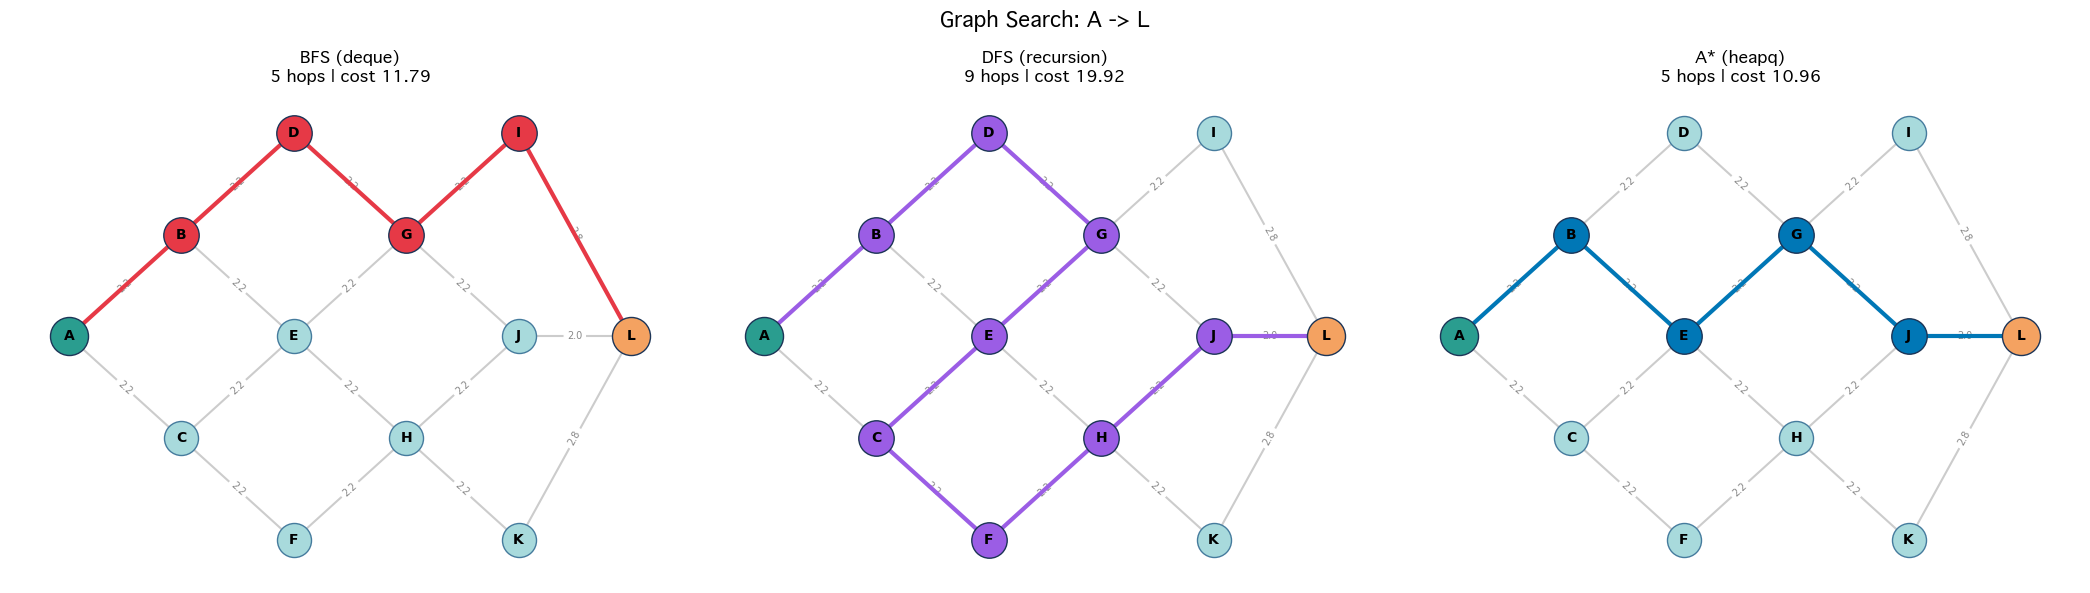

In [7]:
def path_cost(G, path):
    """รวมน้ำหนัก edge ตลอดเส้นทาง"""
    if not path or len(path) < 2:
        return 0.0
    return round(sum(G[u][v]["weight"] for u, v in zip(path, path[1:])), 2)


def run_search(start, goal):
    """รัน BFS/DFS/A* จาก start ไป goal แล้วแสดงผลเทียบกัน"""
    start, goal = start.upper(), goal.upper()
    if start not in G or goal not in G:
        print(f"⚠️  โหนดต้องเป็นหนึ่งใน {sorted(G.nodes())}")
        return

    bfs_p, _ = bfs(G, start, goal)
    dfs_p, _ = dfs_recursive(G, start, goal)
    astar_p, _, astar_c = astar(G, start, goal)

    if bfs_p is None:
        print(f"⚠️  ไปจาก {start} ถึง {goal} ไม่ได้ (คนละกลุ่มของกราฟ)")
        return

    print(f"ค้นหา {start} -> {goal}")
    print(f"  BFS : {bfs_p}  ({len(bfs_p)-1} hops, cost {path_cost(G, bfs_p)})")
    print(f"  DFS : {dfs_p}  ({len(dfs_p)-1} hops, cost {path_cost(G, dfs_p)})")
    print(f"  A*  : {astar_p}  ({len(astar_p)-1} hops, cost {astar_c})  <- optimal")

    results = [
        {"name": "BFS (deque)",     "path": bfs_p,   "color": "#e63946"},
        {"name": "DFS (recursion)", "path": dfs_p,   "color": "#9b5de5"},
        {"name": "A* (heapq)",      "path": astar_p, "color": "#0077b6"},
    ]
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    for ax, res in zip(axes, results):
        hops = len(res["path"]) - 1
        title = f"{res['name']}\n{hops} hops | cost {path_cost(G, res['path'])}"
        draw_single(G, ax, title, path=res["path"], start=start, goal=goal,
                    path_color=res["color"])
    fig.suptitle(f"Graph Search: {start} -> {goal}", fontsize=15, fontweight="bold")
    fig.tight_layout()
    plt.show()


# ตัวอย่างเดิม A -> L
run_search("A", "L")

## 6. 🔎 เลือกโหนดที่อยากหาเอง

**วิธีที่ 1 — แก้ตัวแปรแล้วรัน** (ง่ายสุด): เปลี่ยนค่า `START` / `GOAL` ในเซลล์ถัดไป เช่น หา A → I


ค้นหา A -> I
  BFS : ['A', 'B', 'D', 'G', 'I']  (4 hops, cost 8.96)
  DFS : ['A', 'B', 'D', 'G', 'E', 'C', 'F', 'H', 'J', 'L', 'I']  (10 hops, cost 22.75)
  A*  : ['A', 'B', 'D', 'G', 'I']  (4 hops, cost 8.96)  <- optimal


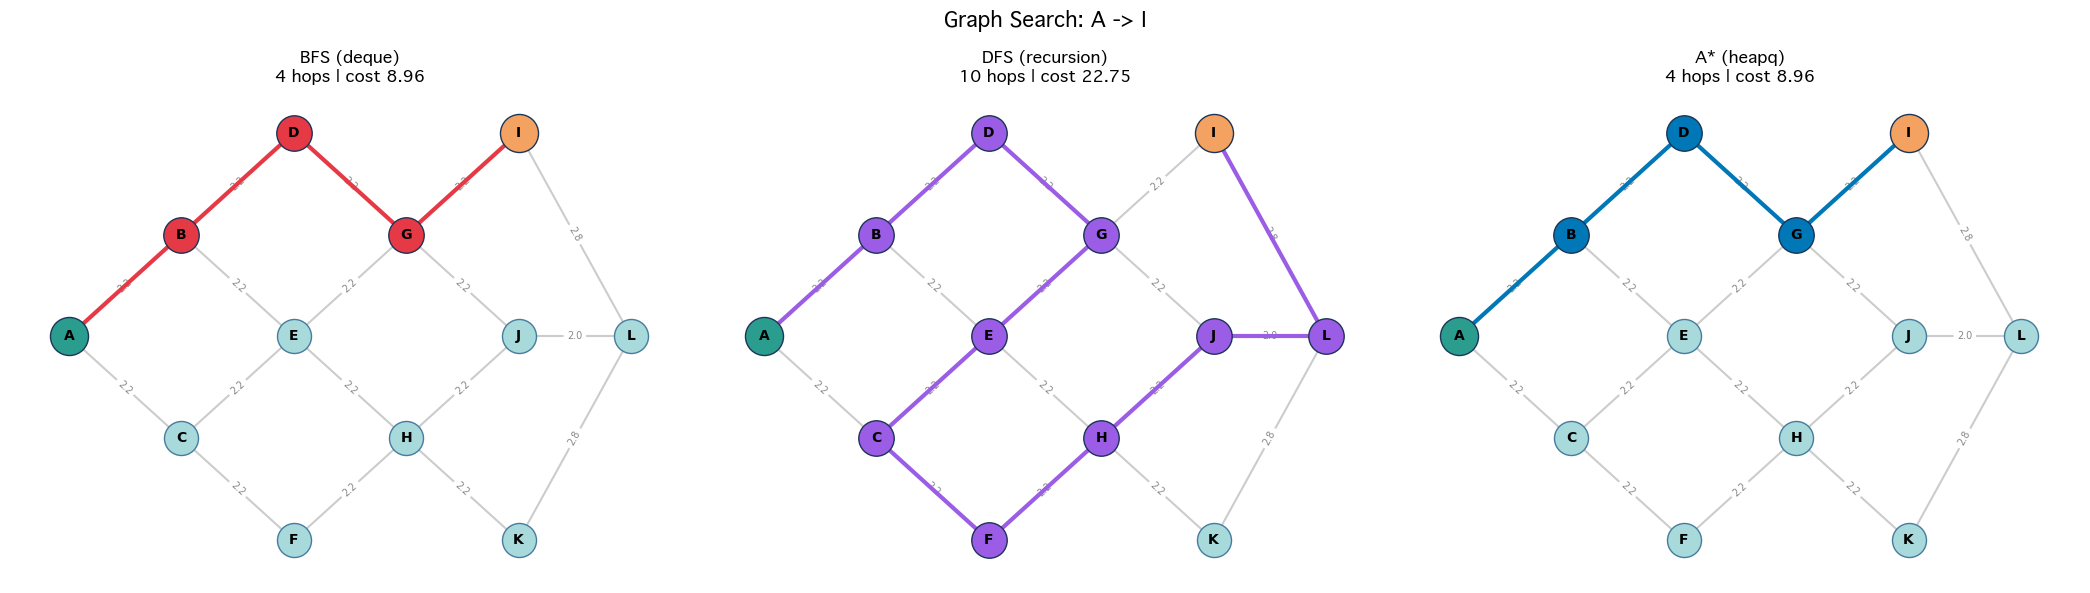

In [8]:
# 👇 แก้สองบรรทัดนี้เป็นโหนดที่ต้องการ แล้วกด Run
START = "A"
GOAL  = "I"

run_search(START, GOAL)

**วิธีที่ 2 — เลือกจาก dropdown แบบ interactive** (ต้องมี `ipywidgets`)

เลื่อนเลือกโหนดเริ่มต้นและปลายทาง โปรแกรมจะคำนวณและวาดรูปใหม่ให้อัตโนมัติทันที


In [9]:
import ipywidgets as widgets

nodes = sorted(G.nodes())
widgets.interact(
    run_search,
    start=widgets.Dropdown(options=nodes, value="A", description="เริ่มต้น:"),
    goal=widgets.Dropdown(options=nodes, value="I", description="เป้าหมาย:"),
);

interactive(children=(Dropdown(description='เริ่มต้น:', options=('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', …

**วิธีที่ 3 — พิมพ์ตอนรัน** (ใช้ `input()`)

รันเซลล์นี้แล้วพิมพ์โหนดที่ช่องกรอกได้เลย


In [ ]:
s = input(f"พิมพ์โหนดเริ่มต้น {sorted(G.nodes())}: ")
g = input("พิมพ์โหนดเป้าหมาย: ")
run_search(s, g)

## สรุป

| อัลกอริทึม | รับประกัน |
|-----------|-----------|
| **BFS** | จำนวนขั้นน้อยสุด (unweighted) |
| **DFS** | เจอเส้นทางใดเส้นทางหนึ่ง (ไม่จำเป็นต้องสั้น) |
| **A\*** | ต้นทุนรวมต่ำสุด (optimal) เมื่อ heuristic admissible |

> เปลี่ยนโหนดในส่วนที่ 6 เพื่อทดลองหาเส้นทางคู่อื่น ๆ ได้ตามต้องการ
